# Notebook 1 — Data Loading & Preprocessing

Loads the raw World Bank EdStats data, filters to valid ISO countries and the 2010–2024 window, and saves cleaned datasets for the next notebook.

**Outputs saved to `data/processed/`:**
- `indicator_data.parquet`
- `indicator_values.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pycountry
import os

pd.set_option('display.max_columns', None)

# Find data directory (works from project root or notebooks/)
if os.path.isdir('data'):
    drive_data_path = os.path.abspath('data')
elif os.path.isdir('../data'):
    drive_data_path = os.path.abspath('../data')
else:
    raise FileNotFoundError('Cannot find data directory')

outputs_path = os.path.join(os.path.dirname(drive_data_path), 'outputs')
processed_path = os.path.join(drive_data_path, 'processed')
os.makedirs(processed_path, exist_ok=True)

os.chdir(drive_data_path)

# Project Context

We are working with an EdTech startup called **Academy**, which provides online learning content aimed at high school and university students.

The manager has requested an **exploratory data analysis (EDA)** to support the company's international expansion strategy.

## Objectives

- Investigate whether **World Bank education datasets** can provide valuable insights for guiding expansion decisions.
- Identify countries with **strong potential demand** for online learning services.
- Explore how this potential may **evolve over time**, using available education and demographic indicators.

## Expected Outcome

Determine whether these datasets can effectively guide Academy in selecting target countries for its international expansion.

# Data Overview

The analysis uses two tables from the **World Bank EdStats** dataset:

| Table | Source File | Description |
|-------|-----------|-------------|
| `indicator_data` | `EdStatsSeries.csv` | Indicator codes and names |
| `indicator_values` | `EdStatsData.csv` | Time-series data (countries Ãƒâ€” indicators Ãƒâ€” years) |

Additionally, a curated list of selected indicators is loaded from `outputs/Indicators.xlsx`.

## 1. Indicator Data (`EdStatsSeries.csv`)

This table maps each indicator to its **Series Code** and **Indicator Name**.

Only these two columns are relevant for the analysis; all other columns (Topic, etc.) will be dropped.

In [2]:
indicator_data = pd.read_csv('EdStatsSeries.csv')

print(f'Shape: {indicator_data.shape}')
print(f'Duplicates: {indicator_data.duplicated().sum()}')
print(f'\nMissing values (proportion):')
print(indicator_data.isna().mean().sort_values(ascending=False))

indicator_data.head()

Shape: (3665, 21)
Duplicates: 0

Missing values (proportion):
Other web links                        1.000000
Unnamed: 20                            1.000000
License Type                           1.000000
Notes from original source             1.000000
Unit of measure                        1.000000
Related indicators                     1.000000
Development relevance                  0.999181
General comments                       0.996180
Limitations and exceptions             0.996180
Statistical concept and methodology    0.993724
Aggregation method                     0.987176
Periodicity                            0.972988
Related source links                   0.941337
Base Period                            0.914325
Other notes                            0.849386
Short definition                       0.411733
Series Code                            0.000000
Long definition                        0.000000
Indicator Name                         0.000000
Topic                     

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Keep only relevant columns
columns_tokeep = ['Series Code', 'Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

,Series Code,Indicator Name
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...


### Indicator Selection

Only the **chosen indicators of interest** are retained from the full dataset. The selection was performed by manually reviewing indicator topics and names in an Excel file, keeping those relevant to education expenditure, enrolment, and internet access.

In [4]:
indicator_list = pd.read_excel(os.path.join(outputs_path, 'Indicators.xlsx'))
codes_to_keep = indicator_list['Series Code'].unique().tolist()
indicator_data = indicator_data[indicator_data['Series Code'].isin(codes_to_keep)]
print(indicator_data)

                Series Code                                     Indicator Name
610          IT.CMP.PCMP.P2                Personal computers (per 100 people)
611          IT.NET.USER.P2                    Internet users (per 100 people)
1658         NY.GDP.MKTP.CD                                  GDP (current US$)
1659         NY.GDP.MKTP.KD                            GDP (constant 2010 US$)
1662         NY.GDP.PCAP.CD                       GDP per capita (current US$)
1930      PRJ.POP.1519.3.MF  Projection: Population age 15-19 in thousands ...
1933      PRJ.POP.1519.4.MF  Projection: Population age 15-19 in thousands ...
2298         SE.SEC.ENRL.GC  Enrolment in secondary general, both sexes (nu...
2307            SE.SEC.ENRR   Gross enrolment ratio, secondary, both sexes (%)
2332            SE.TER.ENRL  Enrolment in tertiary education, all programme...
2376      SE.XPD.SECO.PC.ZS  Government expenditure per secondary student a...
2378      SE.XPD.TERT.PC.ZS  Government expenditure 

## 2. Indicator Values (`EdStatsData.csv`)

This is the **main dataset**, providing time-series data for indicators by country:
- `Country Name` / `Country Code`: Country identification
- `Indicator Name` / `Indicator Code`: Indicator identification
- Year columns (`1970`Ã¢â‚¬â€œ`2100`): Indicator values per year

In [5]:
indicator_values = pd.read_csv('EdStatsData.csv')

print(f'Shape: {indicator_values.shape}')
print(f'\nMissing values (proportion):')
missing_values = indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

indicator_values.head()

Shape: (886930, 70)

Missing values (proportion):


Unnamed: 69       1.000000
2017              0.999839
2016              0.981442
1971              0.959933
1973              0.959924
                    ...   
2010              0.726650
Indicator Name    0.000000
Indicator Code    0.000000
Country Name      0.000000
Country Code      0.000000
Length: 70, dtype: float64


,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,60.999962,61.92268,62.69342,64.383186,65.617767,66.085152,66.608139,67.290451,68.510094,69.033211,69.944908,71.04187,71.693779,71.699097,71.995819,72.602837,70.032722,70.464821,72.645683,71.81176,73.903511,74.425201,75.110817,76.254318,77.245682,78.800522,80.051399,80.805389,81.607063,82.489487,82.685509,83.280342,84.011871,84.195961,85.211998,85.24514,86.101669,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Processing 1: Country Filtering

In this step:
- **Keep only valid ISO countries** using `pycountry`, removing aggregated regions (e.g., "World", "Sub-Saharan Africa").
- **Assess missing values** across year columns to understand data completeness.
- **Drop everything before 2010** and after 2024, as older data is considered outdated and future projections are unreliable.

In [6]:
# Keep only valid ISO-3166 alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]
removed_regions = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]['Country Name'].unique()
print(f'Removed {len(removed_regions)} non-country entities: {list(removed_regions[:5])}...')

indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.info()

Removed 27 non-country entities: ['Arab World', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'Euro area', 'Europe & Central Asia']...


<class 'pandas.core.frame.DataFrame'>
Index: 787975 entries, 91625 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    787975 non-null  object 
 1   Country Code    787975 non-null  object 
 2   Indicator Name  787975 non-null  object 
 3   Indicator Code  787975 non-null  object 
 4   1970            68565 non-null   float64
 5   1971            31697 non-null   float64
 6   1972            31613 non-null   float64
 7   1973            31416 non-null   float64
 8   1974            31570 non-null   float64
 9   1975            83061 non-null   float64
 10  1976            33195 non-null   float64
 11  1977            33267 non-null   float64
 12  1978            33263 non-null   float64
 13  1979            32454 non-null   float64
 14  1980            84668 non-null   float64
 15  1981            34298 non-null   float64
 16  1982            33028 non-null   float64
 17  1983       

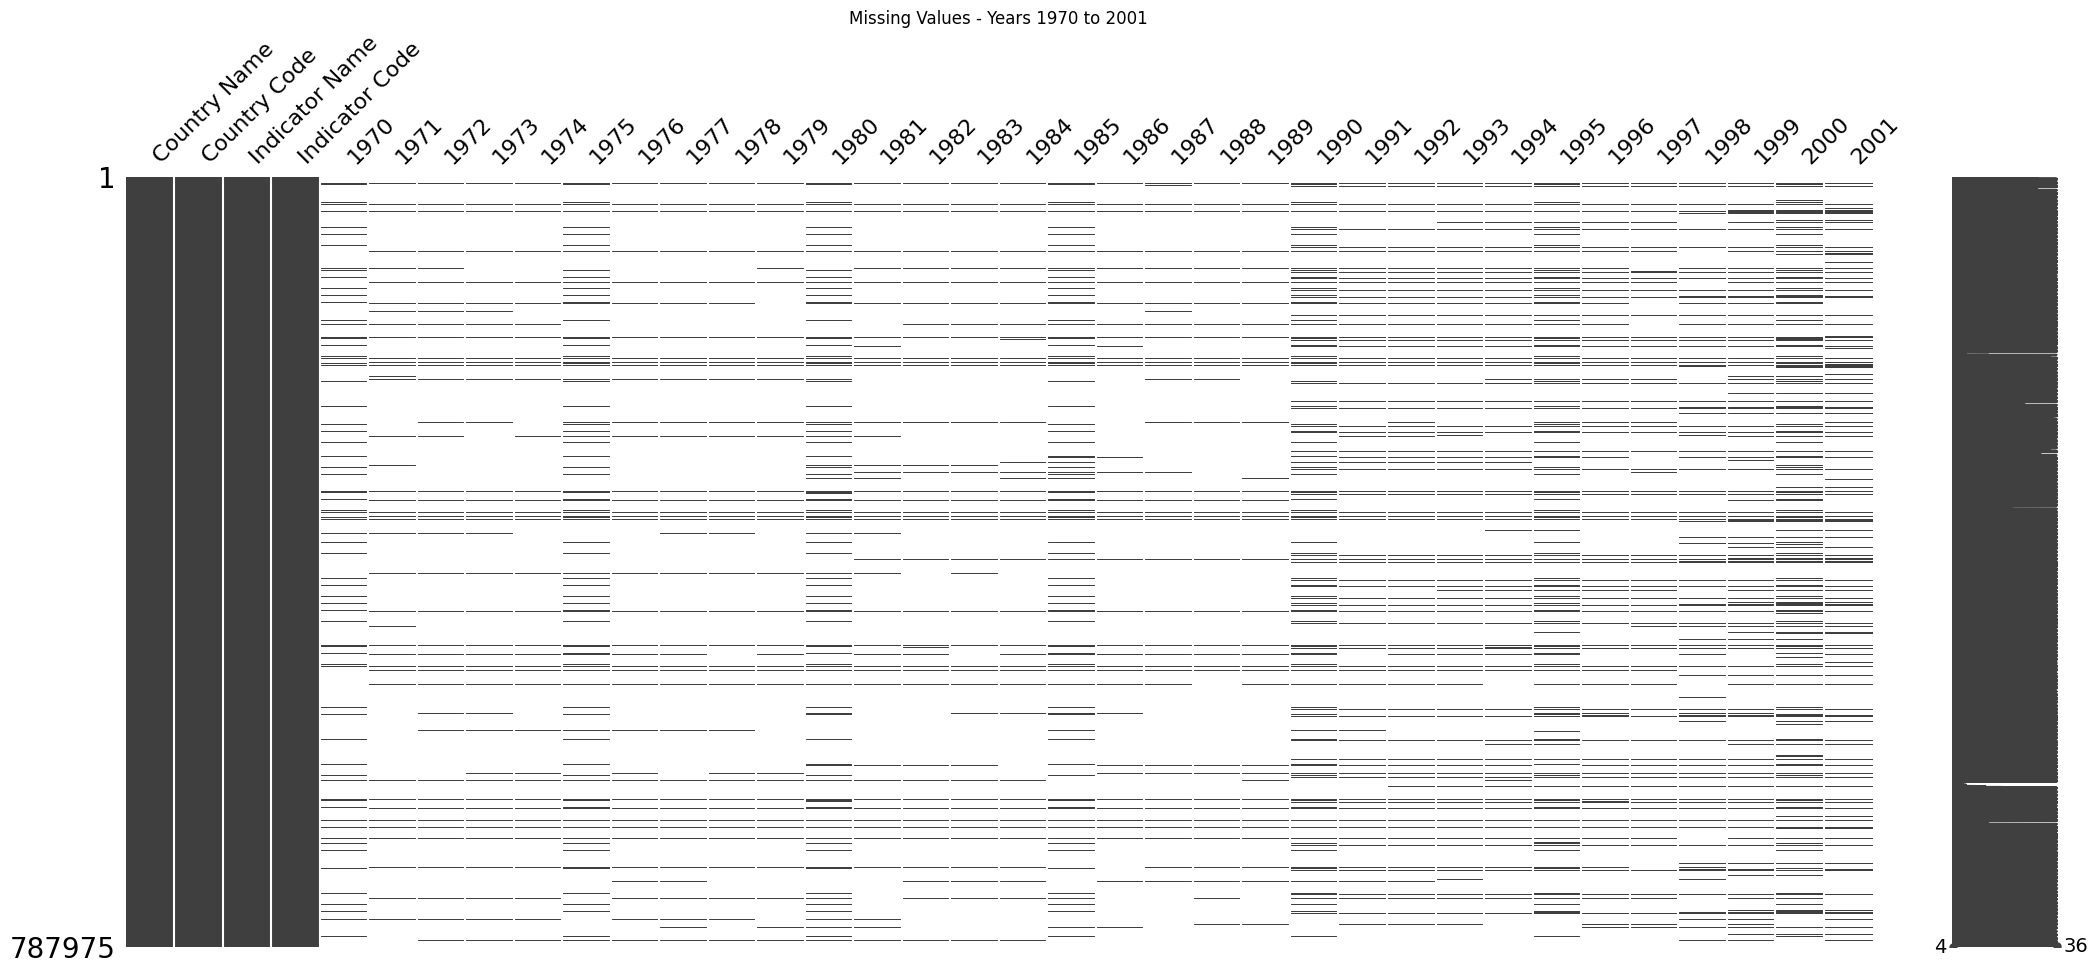

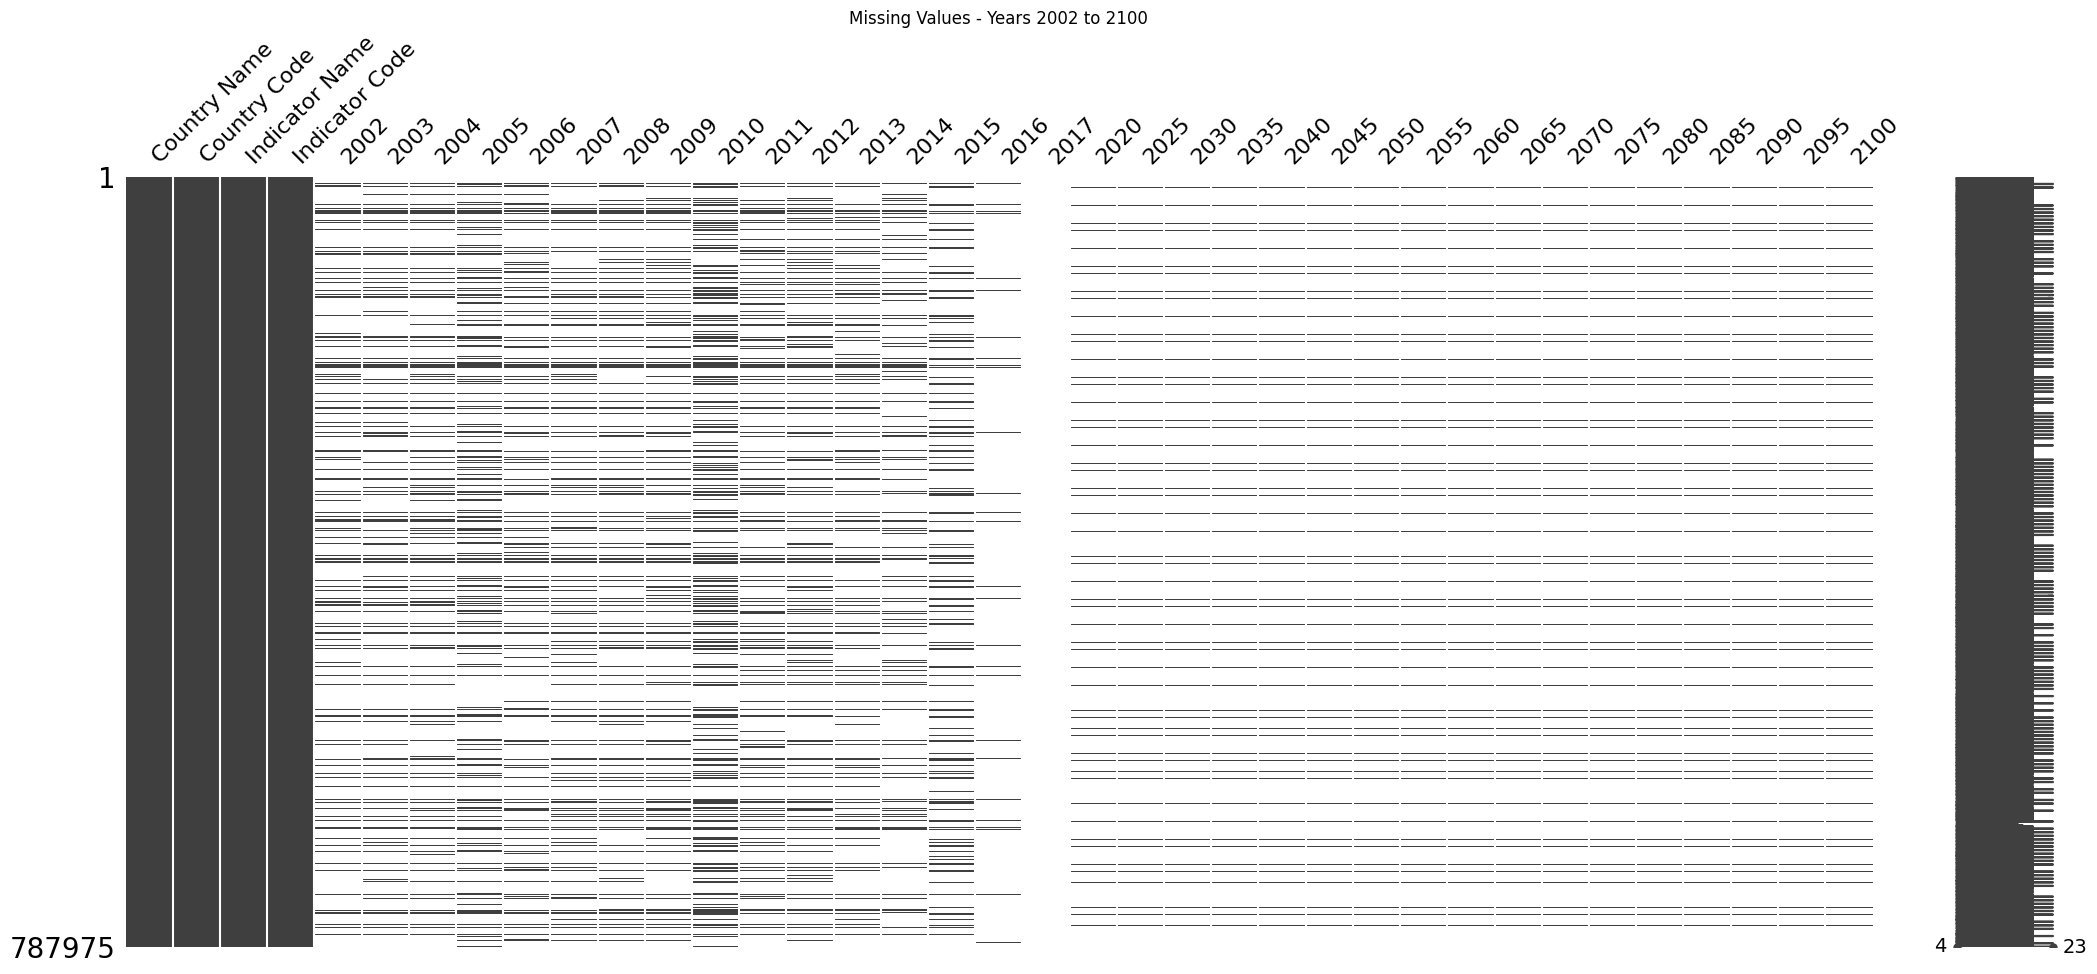

In [7]:
# show all the missing values throughout years

# Identify actual year columns in the DataFrame
all_cols = indicator_values.columns.tolist()
year_cols = [col for col in all_cols if col.isdigit()]

# Split year columns into two groups
half = len(year_cols) // 2
years_group1 = year_cols[:half]
years_group2 = year_cols[half:]


# Plot missingno matrix for the first group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group1])
plt.title('Missing Values - Years 1970 to ' + years_group1[-1])
plt.show()

# Plot missingno matrix for the second group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group2])
plt.title('Missing Values - Years ' + years_group2[0] + ' to 2100')
plt.show()

### Processing 2: Year Range Filtering

All data before **2010** is discarded as outdated. Columns for years **2025Ã¢â‚¬â€œ2100** (projections) are also removed, since we are in 2025 and want to focus on observed data. Only the **2010Ã¢â‚¬â€œ2024** range is retained.

In [8]:
# Keep only 2010-2024 year columns, adding missing years as NaN
year_columns = [str(y) for y in range(2010, 2025)]

for year in year_columns:
    if year not in indicator_values.columns:
        indicator_values[year] = np.nan

indicator_values = indicator_values[
    ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + year_columns
]

display(indicator_values.columns.tolist())

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

## Save Processed Data

Persist cleaned datasets to `data/processed/` for Notebook 2.

In [9]:
indicator_data.to_parquet(os.path.join(processed_path, 'indicator_data.parquet'), index=False)
indicator_values.to_parquet(os.path.join(processed_path, 'indicator_values.parquet'), index=False)
print('Saved indicator_data and indicator_values to data/processed/')

Saved indicator_data and indicator_values to data/processed/
